In [2]:
!pip install torch-geometric


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 85.7 MB/s eta 0:00:00


In [3]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch_geometric.nn import SAGEConv
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

print("PyTorch version:", torch.__version__)
print("CUDA available: ", torch.cuda.is_available())
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:   ", device)


PyTorch version: 2.10.0+cu128
CUDA available:  True
Using device:    cuda


In [4]:
# ── Load all data produced by features.ipynb + graph_builder.ipynb ───────────
# Local path (default)
# BASE = "data/processed"

# Google Colab — uncomment and set your Drive path if running on Colab
from google.colab import drive
drive.mount('/content/drive')
BASE = "/content/drive/MyDrive/sp500-gnn/data/processed"

features_norm  = np.load(f"{BASE}/features.npy")                          # (T, N, F)
targets        = np.load(f"{BASE}/targets_ranked.npy")                    # (T, N)
train_idx      = np.load(f"{BASE}/train_idx.npy")
val_idx        = np.load(f"{BASE}/val_idx.npy")
test_idx       = np.load(f"{BASE}/test_idx.npy")
edge_indices   = np.load(f"{BASE}/edge_indices.npy", allow_pickle=True)
edge_weights   = np.load(f"{BASE}/edge_weights.npy", allow_pickle=True)
tickers        = pd.read_csv(f"{BASE}/tickers.csv").iloc[:, 0].tolist()
feature_names  = pd.read_csv(f"{BASE}/feature_names.csv").iloc[:, 0].tolist()
dates          = pd.to_datetime(pd.read_csv(f"{BASE}/dates.csv").iloc[:, 0])

N_FEATURES = features_norm.shape[2]

print(f"features_norm  : {features_norm.shape}   (T, N, F)")
print(f"targets        : {targets.shape}   (T, N)")
print(f"train_idx      : {train_idx.shape}")
print(f"val_idx        : {val_idx.shape}")
print(f"test_idx       : {test_idx.shape}")
print(f"edge graphs    : {len(edge_indices)}")
print(f"tickers        : {len(tickers)}")
print(f"n_features     : {N_FEATURES}  {feature_names}")


Mounted at /content/drive
features_norm  : (2003, 462, 15)   (T, N, F)
targets        : (2003, 462)   (T, N)
train_idx      : (1295,)
val_idx        : (240,)
test_idx       : (468,)
edge graphs    : 2003
tickers        : 462
n_features     : 15  ['roll_mean_5', 'roll_mean_20', 'roll_std_5', 'roll_std_20', 'mom_12_1', 'mom_6_1', 'mom_3_1', 'mom_1_0', 'reversal_1w', 'sharpe_20', 'sharpe_60', 'rel_strength_20', 'rel_strength_60', 'vol_weighted_mom_5', 'vol_weighted_mom_20']


In [5]:
class StockGNN(nn.Module):
    """
    2-layer GraphSAGE for cross-sectional volatility ranking.

    Key design choices:
      - edge_weight passed to SAGEConv for weighted neighbour aggregation
      - tanh output bounds predictions to (-1, 1), matching the ranked target
        and preventing the model-collapse-to-zero seen without it
    """
    def __init__(self, in_channels, hidden_channels, out_channels, num_layers, dropout):
        super().__init__()
        self.convs = nn.ModuleList()
        self.convs.append(SAGEConv(in_channels, hidden_channels))
        for _ in range(num_layers - 1):
            self.convs.append(SAGEConv(hidden_channels, hidden_channels))
        self.output  = nn.Linear(hidden_channels, out_channels)
        self.dropout = nn.Dropout(dropout)
        self.relu    = nn.ReLU()

    def forward(self, x, edge_index, edge_weight=None):
      for conv in self.convs:
          x = conv(x, edge_index)   # drop edge_weight here
          x = self.relu(x)
          x = self.dropout(x)
      return torch.tanh(self.output(x)).squeeze(-1)


IN_CHANNELS     = N_FEATURES   # inferred from data — currently 15
HIDDEN_CHANNELS = 32
OUT_CHANNELS    = 1
NUM_LAYERS      = 2
DROPOUT         = 0.2

model = StockGNN(IN_CHANNELS, HIDDEN_CHANNELS, OUT_CHANNELS, NUM_LAYERS, DROPOUT).to(device)
print(model)
print(f"\nTotal parameters: {sum(p.numel() for p in model.parameters()):,}")


StockGNN(
  (convs): ModuleList(
    (0): SAGEConv(15, 32, aggr=mean)
    (1): SAGEConv(32, 32, aggr=mean)
  )
  (output): Linear(in_features=32, out_features=1, bias=True)
  (dropout): Dropout(p=0.2, inplace=False)
  (relu): ReLU()
)

Total parameters: 3,105


In [6]:
def make_graph(t):
    """Return (x, edge_index, edge_weight, y) tensors for timestep t."""
    x           = torch.tensor(features_norm[t], dtype=torch.float32).to(device)
    edge_index  = torch.tensor(edge_indices[t],  dtype=torch.long).to(device)
    edge_weight = torch.tensor(edge_weights[t],  dtype=torch.float32).to(device)
    y           = torch.tensor(targets[t],       dtype=torch.float32).to(device)
    return x, edge_index, edge_weight, y


def run_epoch(idx, optimizer=None):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()
    total_loss = 0.0
    with torch.set_grad_enabled(is_train):
        for t in idx:
            x, edge_index, edge_weight, y = make_graph(t)
            pred = model(x, edge_index, edge_weight)
            loss = nn.functional.mse_loss(pred, y)
            if is_train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
            total_loss += loss.item()
    return total_loss / len(idx)


LR       = 0.001
EPOCHS   = 200
PATIENCE = 30

model     = StockGNN(IN_CHANNELS, HIDDEN_CHANNELS, OUT_CHANNELS, NUM_LAYERS, DROPOUT).to(device)
optimizer = optim.Adam(model.parameters(), lr=LR)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-5)

train_losses, val_losses = [], []
best_val, patience_counter, best_weights = float("inf"), 0, None

for epoch in range(1, EPOCHS + 1):
    train_loss = run_epoch(train_idx, optimizer)
    val_loss   = run_epoch(val_idx)
    scheduler.step()

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    if val_loss < best_val:
        best_val, patience_counter = val_loss, 0
        best_weights = {k: v.cpu().clone() for k, v in model.state_dict().items()}
    else:
        patience_counter += 1

    if epoch % 10 == 0:
        print(f"Epoch {epoch:3d} | Train: {train_loss:.6f} | Val: {val_loss:.6f} "
              f"| LR: {scheduler.get_last_lr()[0]:.2e} | Pat: {patience_counter}/{PATIENCE}")

    if patience_counter >= PATIENCE:
        print(f"\nEarly stopping at epoch {epoch}")
        break

model.load_state_dict(best_weights)
print(f"\nBest val loss: {best_val:.6f}")


Epoch  10 | Train: 0.195721 | Val: 0.227850 | LR: 9.94e-04 | Pat: 0/30
Epoch  20 | Train: 0.193012 | Val: 0.228721 | LR: 9.76e-04 | Pat: 9/30
Epoch  30 | Train: 0.191869 | Val: 0.229748 | LR: 9.46e-04 | Pat: 19/30
Epoch  40 | Train: 0.191299 | Val: 0.231466 | LR: 9.05e-04 | Pat: 29/30

Early stopping at epoch 41

Best val loss: 0.227518


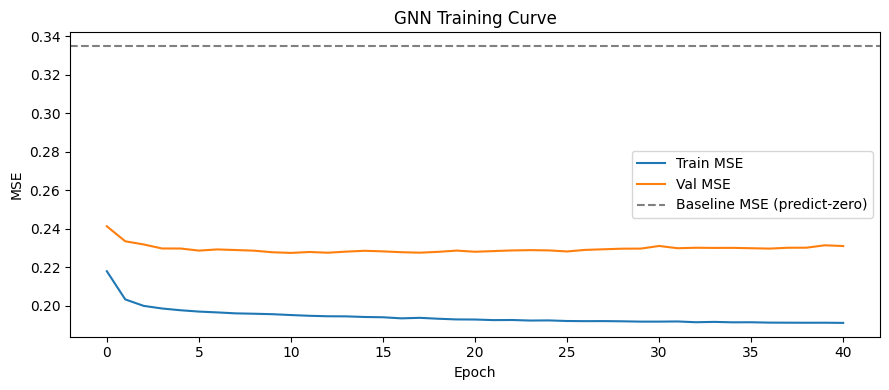

In [7]:
# ── Learning curve ────────────────────────────────────────────────────────────
plt.figure(figsize=(9, 4))
plt.plot(train_losses, label="Train MSE")
plt.plot(val_losses,   label="Val MSE")
plt.axhline(np.mean(targets[val_idx] ** 2), color="gray",
            linestyle="--", label="Baseline MSE (predict-zero)")
plt.xlabel("Epoch"); plt.ylabel("MSE"); plt.title("GNN Training Curve")
plt.legend(); plt.tight_layout(); plt.show()


In [8]:
# ── Ridge baseline ────────────────────────────────────────────────────────────
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error

X_train = features_norm[train_idx].reshape(-1, N_FEATURES)
y_train = targets[train_idx].reshape(-1)
X_val   = features_norm[val_idx].reshape(-1, N_FEATURES)
y_val   = targets[val_idx].reshape(-1)

ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)
val_pred_ridge = ridge.predict(X_val)
baseline_mse   = np.mean(y_val ** 2)

print(f"Baseline MSE (predict zero): {baseline_mse:.6f}")
print(f"Ridge val MSE:               {mean_squared_error(y_val, val_pred_ridge):.6f}")
print(f"Ridge improvement:           "
      f"{(baseline_mse - mean_squared_error(y_val, val_pred_ridge)) / baseline_mse * 100:.2f}%")
print(f"Ridge pred std:              {val_pred_ridge.std():.6f}")
print(f"True target std:             {y_val.std():.6f}")
print("\nRidge coefficients:")
for name, coef in zip(feature_names, ridge.coef_):
    print(f"  {name:<25} {coef:+.4f}")


Baseline MSE (predict zero): 0.334779
Ridge val MSE:               0.265863
Ridge improvement:           20.59%
Ridge pred std:              0.297107
True target std:             0.578601

Ridge coefficients:
  roll_mean_5               -0.0057
  roll_mean_20              -0.0471
  roll_std_5                +0.0450
  roll_std_20               +0.2556
  mom_12_1                  +0.0024
  mom_6_1                   +0.0020
  mom_3_1                   +0.0064
  mom_1_0                   +0.0148
  reversal_1w               +0.0060
  sharpe_20                 -0.0013
  sharpe_60                 -0.1442
  rel_strength_20           +0.0086
  rel_strength_60           +0.1074
  vol_weighted_mom_5        -0.0007
  vol_weighted_mom_20       +0.0400


In [9]:
# ── GNN evaluation — MSE + IC ─────────────────────────────────────────────────
model.eval()
all_preds, all_true = [], []

with torch.no_grad():
    for t in val_idx:
        x, edge_index, edge_weight, y = make_graph(t)
        all_preds.append(model(x, edge_index, edge_weight).cpu().numpy())
        all_true.append(y.cpu().numpy())

all_preds = np.concatenate(all_preds)
all_true  = np.concatenate(all_true)

gnn_mse      = np.mean((all_preds - all_true) ** 2)
ic, _        = spearmanr(all_preds, all_true)
ridge_mse    = mean_squared_error(y_val, val_pred_ridge)
ridge_ic, _  = spearmanr(val_pred_ridge, y_val)

print("─── GNN  (val) ─────────────────────────────")
print(f"  MSE:           {gnn_mse:.6f}")
print(f"  IC (Spearman): {ic:.4f}")
print(f"  Pred range:    [{all_preds.min():.3f}, {all_preds.max():.3f}]")
print("\n─── Ridge (val) ─────────────────────────────")
print(f"  MSE:           {ridge_mse:.6f}")
print(f"  IC (Spearman): {ridge_ic:.4f}")
print("\n─── Baseline ────────────────────────────────")
print(f"  MSE:           {baseline_mse:.6f}")
print(f"\nGNN vs baseline: {(baseline_mse - gnn_mse) / baseline_mse * 100:.2f}%")
print(f"GNN vs Ridge:    {(ridge_mse - gnn_mse) / ridge_mse * 100:.2f}%")


─── GNN  (val) ─────────────────────────────
  MSE:           0.227518
  IC (Spearman): 0.5710
  Pred range:    [-0.891, 1.000]

─── Ridge (val) ─────────────────────────────
  MSE:           0.265863
  IC (Spearman): 0.4778

─── Baseline ────────────────────────────────
  MSE:           0.334779

GNN vs baseline: 32.04%
GNN vs Ridge:    14.42%


─── MSE: GNN vs Ridge ───────────────────────────
  All periods    — GNN: 0.227518  Ridge: 0.265863
  High-stress    — GNN: 0.221538  Ridge: 0.261480
  Low-stress     — GNN: 0.230452  Ridge: 0.268014

─── IC: GNN vs Ridge ────────────────────────────
  All periods    — GNN: 0.5756  Ridge: 0.4771
  High-stress    — GNN: 0.5907  Ridge: 0.4803
  Low-stress     — GNN: 0.5682  Ridge: 0.4756


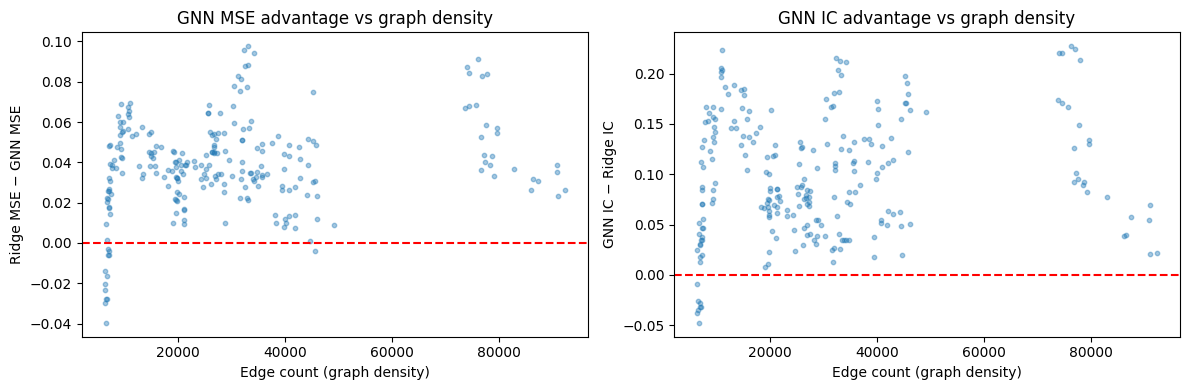

In [10]:
# ── Stress-period analysis ────────────────────────────────────────────────────
# Core hypothesis: GNN outperforms Ridge most during high-correlation (stress) regimes.

gnn_mse_ts, ridge_mse_ts, avg_edges = [], [], []
gnn_ic_ts,  ridge_ic_ts             = [], []

model.eval()
with torch.no_grad():
    for t in val_idx:
        x, edge_index, edge_weight, y = make_graph(t)
        pred_gnn   = model(x, edge_index, edge_weight).cpu().numpy()
        pred_ridge = ridge.predict(features_norm[t])
        true       = targets[t]

        gnn_mse_ts.append(np.mean((pred_gnn - true) ** 2))
        ridge_mse_ts.append(np.mean((pred_ridge - true) ** 2))
        avg_edges.append(edge_indices[t].shape[1])
        gnn_ic_ts.append(spearmanr(pred_gnn, true)[0])
        ridge_ic_ts.append(spearmanr(pred_ridge, true)[0])

gnn_mse_ts   = np.array(gnn_mse_ts)
ridge_mse_ts = np.array(ridge_mse_ts)
avg_edges    = np.array(avg_edges)
gnn_ic_ts    = np.array(gnn_ic_ts)
ridge_ic_ts  = np.array(ridge_ic_ts)

tercile     = np.percentile(avg_edges, 67)
high_stress = avg_edges >= tercile
low_stress  = ~high_stress

print("─── MSE: GNN vs Ridge ───────────────────────────")
for label, mask in [("All periods", slice(None)), ("High-stress", high_stress), ("Low-stress", low_stress)]:
    print(f"  {label:<14} — GNN: {gnn_mse_ts[mask].mean():.6f}  "
          f"Ridge: {ridge_mse_ts[mask].mean():.6f}")
print("\n─── IC: GNN vs Ridge ────────────────────────────")
for label, mask in [("All periods", slice(None)), ("High-stress", high_stress), ("Low-stress", low_stress)]:
    print(f"  {label:<14} — GNN: {np.nanmean(gnn_ic_ts[mask]):.4f}  "
          f"Ridge: {np.nanmean(ridge_ic_ts[mask]):.4f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
gnn_advantage = ridge_mse_ts - gnn_mse_ts
axes[0].scatter(avg_edges, gnn_advantage, alpha=0.4, s=10)
axes[0].axhline(0, color="red", linestyle="--")
axes[0].set_xlabel("Edge count (graph density)")
axes[0].set_ylabel("Ridge MSE − GNN MSE")
axes[0].set_title("GNN MSE advantage vs graph density")
axes[1].scatter(avg_edges, gnn_ic_ts - ridge_ic_ts, alpha=0.4, s=10)
axes[1].axhline(0, color="red", linestyle="--")
axes[1].set_xlabel("Edge count (graph density)")
axes[1].set_ylabel("GNN IC − Ridge IC")
axes[1].set_title("GNN IC advantage vs graph density")
plt.tight_layout(); plt.show()


In [11]:
import os
os.makedirs("models", exist_ok=True)
torch.save(model.state_dict(), "models/stock_gnn_best.pt")
print("Model saved to models/stock_gnn_best.pt")


Model saved to models/stock_gnn_best.pt


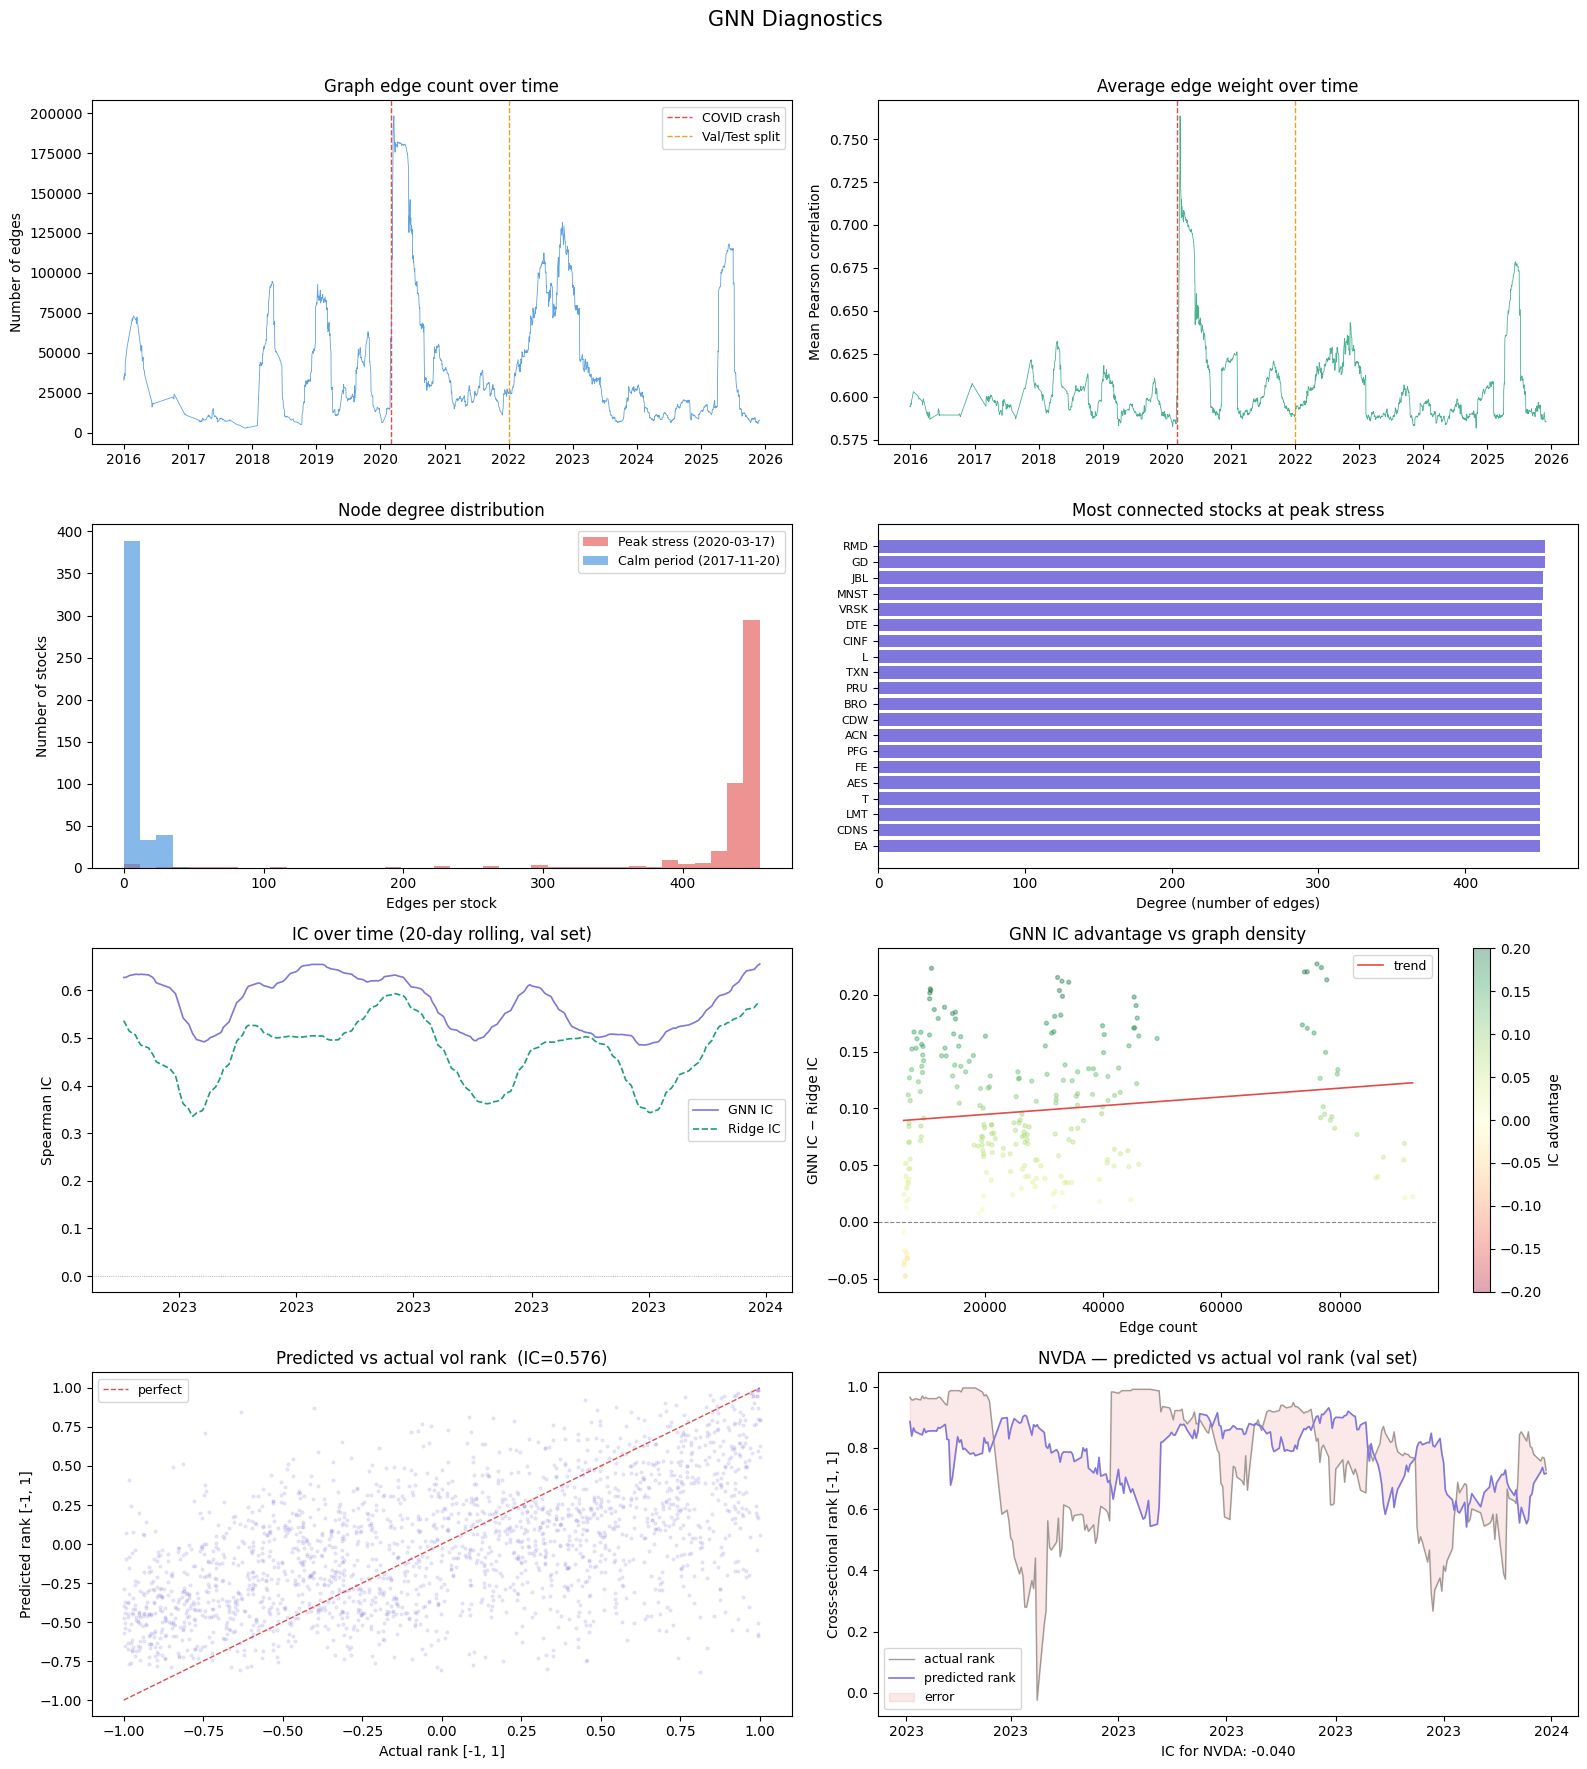

In [12]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
from scipy.stats import spearmanr

fig = plt.figure(figsize=(16, 18))
fig.suptitle("GNN Diagnostics", fontsize=15, fontweight="normal", y=0.98)

# ── pre-compute per-timestep stats over the FULL dataset ─────────────────────
n_total   = len(edge_indices)
all_dates = dates.values  # numpy datetime64

edge_counts  = np.array([edge_indices[t].shape[1] for t in range(n_total)])
avg_weights  = np.array([edge_weights[t].mean() if len(edge_weights[t]) > 0 else 0.0
                         for t in range(n_total)])

# degree of each node at each timestep: count how many edges each stock has
# shape: (n_total, n_stocks)
degree_matrix = np.zeros((n_total, features_norm.shape[1]), dtype=np.int32)
for t in range(n_total):
    if edge_indices[t].shape[1] > 0:
        src = edge_indices[t][0]
        np.add.at(degree_matrix[t], src, 1)

# ── IC over time (val set) ────────────────────────────────────────────────────
model.eval()
val_preds_ts, val_true_ts, val_dates_ts = [], [], []
with torch.no_grad():
    for t in val_idx:
        x, edge_index, edge_weight, y = make_graph(t)
        pred = model(x, edge_index, edge_weight).cpu().numpy()
        val_preds_ts.append(pred)
        val_true_ts.append(targets[t])
        val_dates_ts.append(dates.iloc[t])

ic_ts      = np.array([spearmanr(p, y)[0] for p, y in zip(val_preds_ts, val_true_ts)])
ridge_ic_ts_all = np.array([spearmanr(ridge.predict(features_norm[t]), targets[t])[0]
                             for t in val_idx])
val_dates_arr = np.array(val_dates_ts)

# ══════════════════════════════════════════════════════════════════════════════
# Plot 1 — edge count over time (full dataset)
# ══════════════════════════════════════════════════════════════════════════════
ax1 = fig.add_subplot(4, 2, 1)
ax1.plot(all_dates, edge_counts, linewidth=0.6, color="#378ADD", alpha=0.8)
ax1.axvline(np.datetime64("2020-03-01"), color="#E24B4A", linewidth=1, linestyle="--", label="COVID crash")
ax1.axvline(np.datetime64("2022-01-01"), color="#EF9F27", linewidth=1, linestyle="--", label="Val/Test split")
ax1.set_title("Graph edge count over time", fontsize=12)
ax1.set_ylabel("Number of edges")
ax1.legend(fontsize=9)
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax1.xaxis.set_major_locator(mdates.YearLocator())

# ── Plot 2 — average edge weight over time ───────────────────────────────────
ax2 = fig.add_subplot(4, 2, 2)
ax2.plot(all_dates, avg_weights, linewidth=0.6, color="#1D9E75", alpha=0.8)
ax2.axvline(np.datetime64("2020-03-01"), color="#E24B4A", linewidth=1, linestyle="--")
ax2.axvline(np.datetime64("2022-01-01"), color="#EF9F27", linewidth=1, linestyle="--")
ax2.set_title("Average edge weight over time", fontsize=12)
ax2.set_ylabel("Mean Pearson correlation")
ax2.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax2.xaxis.set_major_locator(mdates.YearLocator())

# ══════════════════════════════════════════════════════════════════════════════
# Plot 3 — degree distribution (snapshot: highest-edge timestep = peak stress)
# ══════════════════════════════════════════════════════════════════════════════
ax3 = fig.add_subplot(4, 2, 3)
peak_t    = int(np.argmax(edge_counts))
calm_t    = int(np.argmin(edge_counts[edge_counts > 0]))
peak_deg  = degree_matrix[peak_t]
calm_deg  = degree_matrix[calm_t]
bins      = np.linspace(0, max(peak_deg.max(), calm_deg.max()) + 1, 40)
ax3.hist(peak_deg, bins=bins, alpha=0.6, color="#E24B4A", label=f"Peak stress ({str(all_dates[peak_t])[:10]})")
ax3.hist(calm_deg, bins=bins, alpha=0.6, color="#378ADD", label=f"Calm period ({str(all_dates[calm_t])[:10]})")
ax3.set_title("Node degree distribution", fontsize=12)
ax3.set_xlabel("Edges per stock")
ax3.set_ylabel("Number of stocks")
ax3.legend(fontsize=9)

# ── Plot 4 — top 20 most connected stocks (peak stress snapshot) ─────────────
ax4 = fig.add_subplot(4, 2, 4)
top20_idx    = np.argsort(degree_matrix[peak_t])[-20:][::-1]
top20_deg    = degree_matrix[peak_t][top20_idx]
top20_labels = [tickers[i] for i in top20_idx]
ax4.barh(range(20), top20_deg, color="#7F77DD")
ax4.set_yticks(range(20))
ax4.set_yticklabels(top20_labels, fontsize=8)
ax4.invert_yaxis()
ax4.set_title(f"Most connected stocks at peak stress", fontsize=12)
ax4.set_xlabel("Degree (number of edges)")

# ══════════════════════════════════════════════════════════════════════════════
# Plot 5 — IC over time: GNN vs Ridge
# ══════════════════════════════════════════════════════════════════════════════
ax5 = fig.add_subplot(4, 2, 5)
window = 20
gnn_ic_smooth   = np.convolve(ic_ts,           np.ones(window)/window, mode="valid")
ridge_ic_smooth = np.convolve(ridge_ic_ts_all, np.ones(window)/window, mode="valid")
smooth_dates    = val_dates_arr[window-1:]
ax5.plot(smooth_dates, gnn_ic_smooth,   color="#7F77DD", linewidth=1.2, label="GNN IC")
ax5.plot(smooth_dates, ridge_ic_smooth, color="#1D9E75", linewidth=1.2, label="Ridge IC", linestyle="--")
ax5.axhline(0, color="#888780", linewidth=0.5, linestyle=":")
ax5.set_title(f"IC over time ({window}-day rolling, val set)", fontsize=12)
ax5.set_ylabel("Spearman IC")
ax5.legend(fontsize=9)
ax5.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

# ── Plot 6 — GNN IC advantage vs edge count (scatter) ───────────────────────
ax6 = fig.add_subplot(4, 2, 6)
val_edge_counts = np.array([edge_indices[t].shape[1] for t in val_idx])
ic_advantage    = ic_ts - ridge_ic_ts_all
sc = ax6.scatter(val_edge_counts, ic_advantage, alpha=0.35, s=8,
                 c=ic_advantage, cmap="RdYlGn", vmin=-0.2, vmax=0.2)
ax6.axhline(0, color="#888780", linewidth=0.8, linestyle="--")
z = np.polyfit(val_edge_counts, ic_advantage, 1)
xline = np.linspace(val_edge_counts.min(), val_edge_counts.max(), 100)
ax6.plot(xline, np.polyval(z, xline), color="#E24B4A", linewidth=1.2, label="trend")
ax6.set_title("GNN IC advantage vs graph density", fontsize=12)
ax6.set_xlabel("Edge count")
ax6.set_ylabel("GNN IC − Ridge IC")
ax6.legend(fontsize=9)
plt.colorbar(sc, ax=ax6, label="IC advantage")

# ══════════════════════════════════════════════════════════════════════════════
# Plot 7 — predicted vs actual rank scatter (val set, sample 2000 points)
# ══════════════════════════════════════════════════════════════════════════════
ax7 = fig.add_subplot(4, 2, 7)
all_p = np.concatenate(val_preds_ts)
all_t = np.concatenate(val_true_ts)
rng   = np.random.default_rng(42)
idx_s = rng.choice(len(all_p), size=min(2000, len(all_p)), replace=False)
ax7.scatter(all_t[idx_s], all_p[idx_s], alpha=0.15, s=4, color="#7F77DD")
ax7.plot([-1, 1], [-1, 1], color="#E24B4A", linewidth=1, linestyle="--", label="perfect")
ax7.set_title(f"Predicted vs actual vol rank  (IC={np.nanmean(ic_ts):.3f})", fontsize=12)
ax7.set_xlabel("Actual rank [-1, 1]")
ax7.set_ylabel("Predicted rank [-1, 1]")
ax7.legend(fontsize=9)

# ── Plot 8 — individual stock: NVDA ─────────────────────────────────────────
ax8 = fig.add_subplot(4, 2, 8)
stock    = "NVDA"
if stock in tickers:
    s_idx = tickers.index(stock)
    s_pred = np.array([val_preds_ts[i][s_idx] for i in range(len(val_idx))])
    s_true = np.array([val_true_ts[i][s_idx]  for i in range(len(val_idx))])
    ax8.plot(val_dates_arr, s_true, color="#888780",  linewidth=1,   label="actual rank",    alpha=0.8)
    ax8.plot(val_dates_arr, s_pred, color="#7F77DD",  linewidth=1.2, label="predicted rank")
    ax8.fill_between(val_dates_arr, s_true, s_pred, alpha=0.12, color="#E24B4A", label="error")
    ax8.set_title(f"{stock} — predicted vs actual vol rank (val set)", fontsize=12)
    ax8.set_ylabel("Cross-sectional rank [-1, 1]")
    ax8.legend(fontsize=9)
    ax8.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    s_ic, _ = spearmanr(s_pred, s_true)
    ax8.set_xlabel(f"IC for {stock}: {s_ic:.3f}")

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()